![Ironhack logo](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

# 01 | Exploratory Data Analysis

*Project 1 — SQL: From Data to Insight*

**Team:**
**Dataset:**

---

Understanding your data before you design anything. You cannot decide which tables you need until you know which columns repeat, which are broken, and which identify a row.

> **Done when:** you can name the 3+ tables you are going to build, you have written down at least 2 research questions, and you know every data-quality problem notebook 02 will have to fix.

The sections below are a suggested route, not a form to fill in. Add sections, drop them, reorder them — what is graded is the analysis, not whether you kept the scaffold.

---
## 0. Setup

In [1]:
%pip install openpyxl
%pip show openpyxl
%pip install python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Name: openpyxl
Version: 3.1.5
Summary: A Python library to read/write Excel 2010 xlsx/xlsm files
Home-page: https://openpyxl.readthedocs.io
Author: See AUTHORS
Author-email: charlie.clark@clark-consulting.eu
License: MIT
Location: c:\Users\rkham\AppData\Local\Programs\Python\Python311\Lib\site-packages
Requires: et-xmlfile
Required-by: 
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
sys.path.append("..")          # so `src` is importable from inside notebooks/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.functions import *

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

---
## 1. Load the raw data

Run `python download_data.py <payments|airbnb|retail>` from the repo root first. Your files land in `data/raw/`, which is gitignored.

In [ ]:
# Puting all private info in extra file, so its not available for public and than retrieving it
from dotenv import load_dotenv
import os

load_dotenv()

data_path = os.getenv("DATA_PATH")

if data_path is None:
    raise ValueError("DATA_PATH is not set. Create a .env file first.")

In [4]:
raw_data = data_path
print(data_path)

C:\Users\rkham\OneDrive\Desktop\ironhack_project\project-1-eda-sql\data\raw\rawdata.xlsx


---
## 2. First look

Shape, column types, a handful of rows. What is one row of this data?

In [6]:
df = pd.read_excel(raw_data)


In [7]:
df.shape

(1902, 341)

In [8]:
df.head()

,year,country,countryn,iso,iso3n,cpds1,poco,eu,emu,gov_right1,gov_cent1,gov_left1,gov_party,gov_new,gov_gap,gov_chan,gov_right2,gov_cent2,gov_left2,gov_right3,gov_cent3,gov_left3,gov_sup,gov_type,year_01,country_01,elect,vturn,social1,social2,social3,social4,social5,social6,social7,social8,social9,leftsoc1,leftsoc2,leftsoc3,leftsoc4,leftsoc5,comm1,comm2,comm3,comm4,postcom1,postcom2,agrarian1,agrarian2,...,survivor_pmp,incapben_pmp,health_pmp,family_pmp,almp_pmp,unemp_pmp,housing_pmp,othsocx_pmp,year_10,country_10,educexp_gov,educexp_gov_ipol,educexp_public,educexp_public_ipol,educexp_private,educexp_private_ipol,educatt_minimal,educatt_minimal_ipol,educatt_tertiary,educatt_tertiary_ipol,year_11,country_11,fallow_pmp,mpleave_pmp,othfam_c_pmp,childcare_pmp,homehelp_pmp,othfam_k_pmp,servadmi_pmp,training_pmp,jobrot_pmp,incent_pmp,disabled_pmp,jobcrea_pmp,startup_pmp,compen_pmp,earretir_pmp,year_12,country_12,emprot_reg,emprot_temp,prefisc_gini,pretran_gini,postfisc_gini,pop,pop15_64,pop65,elderly,year_13,country_13
0,1960,Australia,1,AUS,36,1,0.0,0.0,0.0,100.0,0.0,0.0,1.0,0.0,0.0,0.0,100.0,0.0,0.0,63.10,0.0,0.0,63.10,2.0,1960,Australia,NaT,95.5,42.8,7.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.3,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1960,Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1960,Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1960,Australia,NaN,NaN,NaN,NaN,NaN,10329.8,6355.9,889.8,8.613913,1960,Australia
1,1961,Australia,1,AUS,36,1,0.0,0.0,0.0,100.0,0.0,0.0,1.0,0.0,0.0,1.0,100.0,0.0,0.0,62.80,0.0,0.0,62.80,2.0,1961,Australia,1961-12-09,95.3,47.9,7.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.5,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1961,Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1961,Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1961,Australia,NaN,NaN,NaN,NaN,NaN,10534.4,6489.2,909.8,8.636467,1961,Australia
2,1962,Australia,1,AUS,36,1,0.0,0.0,0.0,100.0,0.0,0.0,1.0,0.0,0.0,0.0,100.0,0.0,0.0,50.80,0.0,0.0,50.80,2.0,1962,Australia,NaT,95.3,47.9,7.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.5,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1962,Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1962,Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1962,Australia,NaN,NaN,NaN,NaN,NaN,10733.3,6633.4,929.1,8.656238,1962,Australia
3,1963,Australia,1,AUS,36,1,0.0,0.0,0.0,100.0,0.0,0.0,1.0,0.0,0.0,1.0,100.0,0.0,0.0,51.14,0.0,0.0,51.14,2.0,1963,Australia,1963-11-30,95.7,45.5,7.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.9,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1963,Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1963,Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1963,Australia,NaN,NaN,NaN,NaN,NaN,10936.7,6774.2,948.9,8.676292,1963,Australia
4,1964,Australia,1,AUS,36,1,0.0,0.0,0.0,100.0,0.0,0.0,1.0,0.0,0.0,0.0,100.0,0.0,0.0,59.00,0.0,0.0,59.00,2.0,1964,Australia,NaT,95.7,45.5,7.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.9,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1964,Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1964,Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1964,Australia,NaN,NaN,NaN,NaN,NaN,11158.5,6921.9,964.2,8.640946,1964,Australia


---
## 3. Data quality

Missing values, duplicates, numbers stored as text, dates stored as strings. Write down what you find — this is the to-do list for notebook 02.

In [9]:
#General info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1902 entries, 0 to 1901
Columns: 341 entries, year to country_13
dtypes: datetime64[us](1), float64(307), int64(17), object(1), str(15)
memory usage: 4.9+ MB


In [10]:
#Missing values
missing_values = df.isna().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

lrid          1857
lsec          1857
lmin          1857
lexe          1857
ljud          1857
              ... 
sconserv12       6
eu               6
right6           6
poco             6
pop              2
Length: 309, dtype: int64

In [11]:
#Duplicated values
df.duplicated().sum()

np.int64(0)

In [12]:
#check if the most important columns for our research are unique
df.duplicated(subset=["country", "year"]).sum()

np.int64(0)

In [13]:
#Data types
df.dtypes.value_counts()

float64           307
int64              17
str                15
datetime64[us]      1
object              1
Name: count, dtype: int64

In [14]:
#Count number of distinct elements in country column
df["country"].nunique()

36

In [15]:
#Check the counties spelling
df["country"].unique()

<StringArray>
[     'Australia',        'Austria',        'Belgium',       'Bulgaria',
         'Canada',        'Croatia',         'Cyprus', 'Czech Republic',
        'Denmark',        'Estonia',        'Finland',         'France',
        'Germany',         'Greece',        'Hungary',        'Iceland',
        'Ireland',          'Italy',          'Japan',         'Latvia',
      'Lithuania',     'Luxembourg',          'Malta',    'Netherlands',
    'New Zealand',         'Norway',         'Poland',       'Portugal',
        'Romania',       'Slovakia',       'Slovenia',          'Spain',
         'Sweden',    'Switzerland', 'United Kingdom',            'USA']
Length: 36, dtype: str

In [16]:
#Check if the year range is what is announced in data description
df["year"].min(), df["year"].max()

(np.int64(1960), np.int64(2023))

In [17]:
#Check if all countries have data for all years
df["year"].value_counts().sort_index()

year
1960    21
1961    21
1962    21
1963    21
1964    21
        ..
2019    36
2020    36
2021    36
2022    36
2023    36
Name: count, Length: 64, dtype: int64

In [ ]:
# Check if countries have country_id to use it as primary key for later. if not, then find the best candidate for this
import re

country_id_columns = [
    col for col in df.columns
    if re.search(r"country|id", str(col), re.IGNORECASE)
]

print(country_id_columns) #there is a countryn column wich we possibly could use as 
print(len(df["countryn"].unique()))#number of country looks like a good pretendent


['country', 'countryn', 'country_01', 'country_02', 'country_03', 'country_04', 'lrid', 'country_05', 'country_06', 'country_07', 'country_08', 'country_09', 'country_10', 'country_11', 'country_12', 'country_13']
36


---
## 4. Distributions

The numeric columns you care about, and the outliers you will have to decide about.

In [19]:
numeric_columns = [
    "realgdpgr",
    "unemp",
    "inflation"
]

df[numeric_columns].describe()

,realgdpgr,unemp,inflation
count,1828.000000,1834.000000,1811.000000
mean,2.820562,6.464583,5.426491
std,3.439066,4.318762,15.318944
min,-21.374046,0.000000,-4.447547
25%,1.374486,3.500000,1.648223
50%,2.929554,5.800000,3.041363
75%,4.668350,8.500000,6.152574
max,22.344065,27.800000,552.083514


<Axes: >

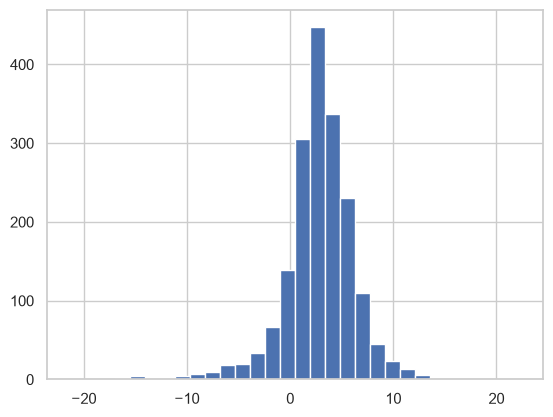

In [ ]:
df["realgdpgr"].hist(bins=30)
#gdp data have a normal distribution slightly moved to the right

<Axes: >

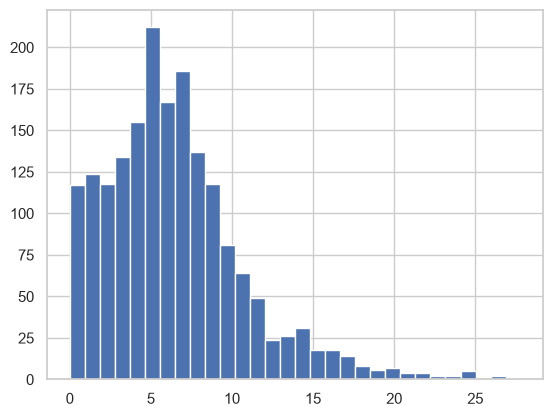

In [ ]:
df["unemp"].hist(bins=30)
#A histogram is right skewed 
#Right Skewed Distribution: Mode < Median < Mean

(0.0, 40.0)

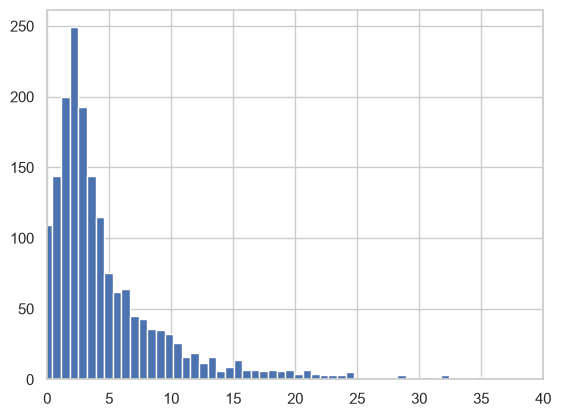

In [ ]:
df["inflation"].hist(bins=800)
plt.xlim(0, 40)

# histogram for inflation data shows a strongly right-skewed distribution
# most inflation observations appear concentrated roughly around 0–10%, while a small number of observations extend much farther to the right.

<Axes: >

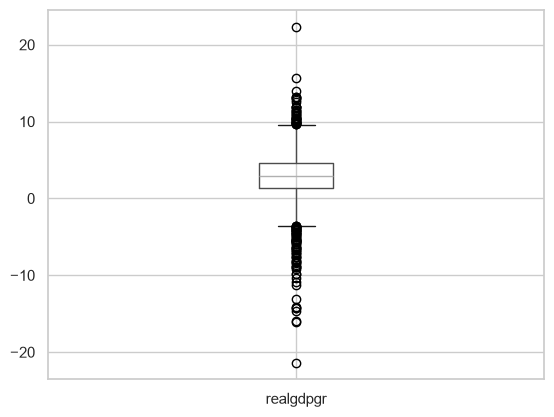

In [21]:
df.boxplot(column="realgdpgr")

<Axes: >

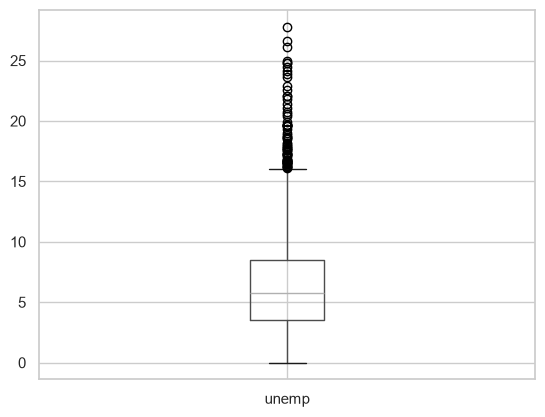

In [22]:
df.boxplot(column="unemp")

<Axes: >

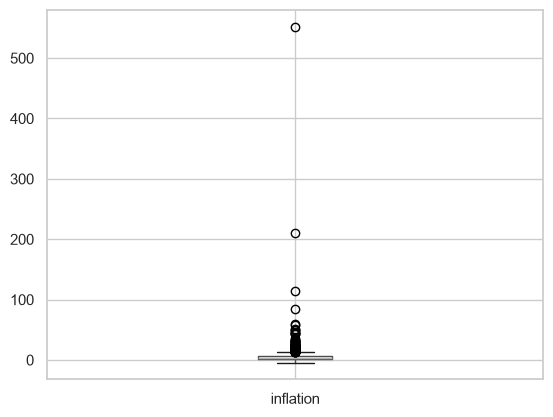

In [23]:
df.boxplot(column="inflation")

In [47]:
q1 = df["inflation"].quantile(0.25)
q3 = df["inflation"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 1.6482231165748549
Q3: 6.15257447973025
IQR: 4.504351363155395
Lower bound: -5.108303928158238
Upper bound: 12.909101524463342


In [48]:
inflation_outliers = df[
    (df["inflation"] < lower_bound) |
    (df["inflation"] > upper_bound)
]

inflation_outliers[["country", "year", "inflation"]]

,country,year,inflation
14,Australia,1974,15.416667
15,Australia,1975,15.162455
16,Australia,1976,13.322884
200,Bulgaria,1998,18.610422
224,Bulgaria,2022,12.991766
...,...,...,...
1790,United Kingdom,1976,16.559525
1791,United Kingdom,1977,15.840272
1793,United Kingdom,1979,13.421286
1794,United Kingdom,1980,17.965925


In [50]:
df.nlargest(10, "inflation")[
    ["country", "year", "inflation"]
]

,country,year,inflation
1565,Slovenia,1990,552.083514
1567,Slovenia,1992,209.933757
1566,Slovenia,1991,114.832925
805,Iceland,1983,83.950046
1505,Romania,1998,59.036145
802,Iceland,1980,58.528428
803,Iceland,1981,51.793249
804,Iceland,1982,50.243224
797,Iceland,1975,49.361340
1507,Romania,2000,45.833333


In [51]:
df_2000_2019 = df[
    df["year"].between(2000, 2019)
]

df_2000_2019.nlargest(10, "inflation")[
    ["country", "year", "inflation"]
]

,country,year,inflation
1507,Romania,2000,45.833333
1508,Romania,2001,34.642857
1509,Romania,2002,22.281167
1510,Romania,2003,15.401302
1053,Latvia,2008,15.170670
830,Iceland,2008,12.694402
1541,Slovakia,2000,12.035777
831,Iceland,2009,12.003117
210,Bulgaria,2008,11.980440
1511,Romania,2004,11.842105


The inflation distribution is strongly right-skewed and contains several extreme observations. The boxplot identifies many values as statistical outliers because most observations are concentrated at relatively low inflation rates. These observations require further investigation before deciding whether they represent data-quality issues or genuine economic events.

---
## 5. Categorical columns

**This is the section that feeds tomorrow.** A column with few distinct values repeated over many rows is a lookup table waiting to happen. Find them.

In [24]:
categorical_columns = df.select_dtypes(include=["object"]).columns

categorical_columns

C:\Users\rkham\AppData\Local\Temp\ipykernel_21840\566229202.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns


Index(['country', 'iso', 'country_01', 'country_02', 'country_03',
       'country_04', 'country_05', 'country_06', 'kaopen', 'country_07',
       'country_08', 'country_09', 'country_10', 'country_11', 'country_12',
       'country_13'],
      dtype='str')

In [25]:
df[categorical_columns].nunique().sort_values()

kaopen        27
country       36
country_01    36
iso           36
country_03    36
country_04    36
country_05    36
country_02    36
country_06    36
country_07    36
country_08    36
country_09    36
country_10    36
country_11    36
country_12    36
country_13    36
dtype: int64

In [26]:
df["gov_party"].value_counts(dropna=False)

gov_party
1.0    801
3.0    334
2.0    325
5.0    234
4.0    195
NaN     13
Name: count, dtype: int64

In [27]:
df["country"].value_counts(dropna=False)

country
Australia         64
Austria           64
Belgium           64
Canada            64
Denmark           64
Finland           64
France            64
Germany           64
Greece            64
Iceland           64
Ireland           64
Italy             64
Japan             64
Luxembourg        64
Netherlands       64
New Zealand       64
Norway            64
Sweden            64
Switzerland       64
United Kingdom    64
USA               64
Malta             58
Portugal          49
Cyprus            48
Spain             47
Bulgaria          34
Czech Republic    34
Hungary           34
Romania           34
Slovakia          34
Slovenia          34
Poland            33
Estonia           32
Lithuania         32
Latvia            31
Croatia           24
Name: count, dtype: int64

In [28]:
df["gov_party"].nunique()

5

---
## 6. Research questions

At least two, written here. Specific, answerable with this data, and with an answer you could be wrong about. For each one, say what you expect and why.

1. GDP growth and government composition
Research question:
How does average real GDP growth differ across government political compositions between 2000 and 2019?
Expectation:
I expect to observe some differences in average GDP growth between government composition categories, although I do not expect political composition alone to explain these differences because economic growth is influenced by many other factors.
2. Unemployment and government composition
Research question:
How does the unemployment rate differ across government political compositions between 2000 and 2019?
Expectation:
I expect unemployment rates to vary across government composition categories. However, I expect substantial variation within each category because unemployment is also influenced by country-specific conditions and broader economic cycles.
3. Inflation — optional but useful
Research question:
How does inflation differ across government political compositions between 2000 and 2019?
Expectation:
I expect inflation to show differences across government composition categories, but I also expect considerable variation between countries and years.
These work well because you could genuinely be wrong. For example, your SQL analysis might show virtually no meaningful difference in average GDP growth between the categories. That's still a valid result.

---
## 7. Into notebook 02

The tables you are going to build, and the problems you have to fix first.

Tables to build
1. countries — lookup table
- country_id — primary key
- country_name
- iso_code
2. government_types — lookup table
- government_type_id — primary key
- government_type
3. country_year — main analytical table
- observation_id — primary key
- country_id — foreign key → countries
- government_type_id — foreign key → government_types
- year
- left_percentage
- centre_percentage
- right_percentage
- gdp_growth
- unemployment
- inflation

Before loading the data into SQLite, I need to:
- select only the columns required for the analysis;
- filter the dataset to the selected period, 2000-2019;
- handle missing values in the selected political and economic variables;
- verify and correct data types where necessary;
- check duplicate country-year observations;
- check categorical values for inconsistent labels;
- investigate extreme values in GDP growth, unemployment and inflation before deciding whether they should be retained;
- transform repeated country and government-composition values into lookup tables;
- create primary and foreign keys for the relational database.

## Additional improvemets for data security
-added .env file where i store all the paths and keys so they are not available to public